In [20]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [12]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

## Qubit
* Any physical system that has a property that assumes only two possible values can act as a quantum bit.
* Some examples are 
    * spin of an electron
    * polarization of a photon
    * first two states of an anharmonic oscillator (superconduction LC circuits)
* The state describing the property is a unit vector in a Hilbert space $\mathcal{H}$ of dimension 2.
* Two orthogonal vectors forming a basis are selected as $\ket{0}$ (read as **ket 0**) and $\ket{1}$.  
* Any state of a qubit can be written as $$\ket{\psi} = a\ket{0} + b\ket{1}$$ such that $a,b$ are complex numbers satisfying the normalization condition $$|a|^2 + |b|^2 = 1$$

### Exercise
* Show that $$\ket{\psi} = e^{i\gamma}(\cos\frac{\theta}{2} \ket{0} + e^{i\varphi}\sin\frac{\theta}{2}\ket{1})$$ with $0\leq \theta\leq \pi$ and $0\leq \varphi\leq 2\pi$.
    * The reason for using $\frac{\theta}{2}$ instead of $\theta$ will become clear when we consider visualization of the state.

## Measurement
* Measurement is a process via which a qubit interacts with a measuring device and its state collapses to one of the basis vectors.
* If a qubit is in state $\ket{\psi} = a\ket{0} + b\ket{1}$, then after measurement, it's state becomes either
    * $\ket{0}$ with probability $|a|^2$, or
    * $\ket{1}$ with probability $|b|^2$
* Due to this probability interpretation, the coefficients $a$ and $b$ are called **probability amplitudes** (or simply amplitudes).
    * This is also the reason why we require the state vector to be of unit length.

## Creating state vectors in qiskit
[quantum_info](https://quantum.cloud.ibm.com/docs/en/api/qiskit/quantum_info)
* Import `Statevector` from `qiskit.quantum_info`
* Import `numpy` for mathematics

In [8]:
from qiskit.quantum_info import Statevector
import numpy as np

* Create coefficient array

In [2]:
a = 1/np.sqrt(2)
b = 1/np.sqrt(2)
coef = [a, b]

* Use the coefficient array in `Statevector` to create state $\ket{\psi}$.

In [3]:
psi = Statevector(coef)
print("A qubit state:")
psi.draw("latex")

A qubit state:


<IPython.core.display.Latex object>

### Exercise: 
Create following states:
* $\frac{1}{\sqrt{2}}|0\rangle - \frac{1}{\sqrt{2}}|1\rangle$
* $\frac{\sqrt{3}}{2}|0\rangle + \frac{1}{2}|1\rangle$
* $\frac{\sqrt{3}}{2}|0\rangle + i\frac{1}{2}|1\rangle$

## States with angles
* Use `numpy` built-in functions `cos, sin, exp`.
* Complex number $i=\sqrt{-1}$ is represented by `j` in `numpy`. 

In [38]:
theta = np.pi/3
phi = np.pi/3
a = np.cos(theta/2)
b = np.exp(1j * phi) * np.sin(theta/2)
coef = [a, b]
psi = Statevector(coef)
print("State from angles:")
psi.draw("latex")

State from angles:


<IPython.core.display.Latex object>

## Normalizing states
* Sometimes the normalization condition may not be there to start with, i.e. we may have vector $a\ket{0} + b\ket{1}$ but $|a|^2 + |b|^2\neq 1$.
* To normalize, divide the state with $\sqrt{|a|^2 + |b|^2}$.

In [5]:
a = 1/np.sqrt(2)
b = 2j
coeff = [a, b]
norm = np.linalg.norm(coeff) # calculates norm sqrt{|a|^2 + |b|^2}
unket = Statevector(coeff) # un-normalized state
ket = Statevector(coeff/norm) # normalized state
print("Un-normalized state:")
display(unket.draw('latex')) # prints un-normalized state
print("Normalized state:")
display(ket.draw('latex')) # prints normalized state

Un-normalized state:


<IPython.core.display.Latex object>

Normalized state:


<IPython.core.display.Latex object>

## Special states
* There are some special qubit states that occur frequently. Qiskit provides labels for them to create.
$$\begin{aligned}
\ket{+} &= \frac{1}{\sqrt{2}}[\ket{0} + \ket{1}]\\
\ket{-} &= \frac{1}{\sqrt{2}}[\ket{0} - \ket{1}]\\
\ket{r} &= \frac{1}{\sqrt{2}}[\ket{0} + i\ket{1}]\\
\ket{l} &= \frac{1}{\sqrt{2}}[\ket{0} - i\ket{1}]
\end{aligned}$$

In [6]:
display(Statevector.from_label('+').draw("latex"))
display(Statevector.from_label('-').draw("latex"))
display(Statevector.from_label('r').draw("latex"))
display(Statevector.from_label('l').draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Density operator of a qubit
* In addition to representing state of a qubit using a vector $\ket{\psi}$, there is an equivalent representation as an outer product.
* This outer product is called density operator $\rho$ given by
                    $$\rho = \outpro{\psi}{\psi}$$
* The dual vector $\bra{\psi}$ is called **bra** vector obtained by taking complex conjugate of coefficients. $$\begin{aligned}\ket{\psi} &= a\ket{0} + b\ket{1}\\ \bra{\psi} &= a^*\bra{0} + b^*\bra{1}\end{aligned}$$
* The density operator becomes 
        $$\begin{aligned}
        \rho &= \outpro{\psi}{\psi}\\
             &= [a\ket{0} + b\ket{1}][a^*\bra{0} + b^*\bra{1}]\\
             &= aa^*\outpro{0}{0} + ab^*\outpro{0}{1} + ba^*\outpro{1}{0} + bb^*\outpro{1}{1}\\
             &= \begin{bmatrix}|a|^2 & ab^*\\ ba^* & |b|^2\end{bmatrix}
        \end{aligned}$$
* Normalization condition implies that the sum of diagonal elements must be equal to 1. This is stated as **trace** function $$tr(\rho) = |a|^2 + |b|^2 = 1$$

### Exercise
* Express the density operator for the general representation of a qubit state.
$$\rho = \begin{bmatrix}
\cos^2\frac{\theta}{2} & e^{-i\varphi}\sin\frac{\theta}{2}\cos\frac{\theta}{2}\\
e^{i\varphi}\sin\frac{\theta}{2}\cos\frac{\theta}{2} & \sin^2\frac{\theta}{2}
\end{bmatrix} = \frac{1}{2}\begin{bmatrix}
1 + \cos\theta & e^{-i\varphi}\sin\theta\\
e^{i\varphi}\sin\theta & 1-\cos\theta\end{bmatrix}$$

## Density operator from statevector
* Use `DensityMatrix` from `qiskit.quantum_info`

In [13]:
from qiskit.quantum_info import Statevector, DensityMatrix
import numpy as np

# 1. Create a statevector (e.g., the |+> state)
psi = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])

# 2. Convert to a density matrix
rho = DensityMatrix(psi)

# Display the matrix
rho.draw('latex')

<IPython.core.display.Latex object>

## Pauli matrices
$$
\begin{aligned}
\sigma_1 = \sigma_x &= \begin{bmatrix}0 & 1\\ 1 & 0\end{bmatrix} = \outpro{0}{1} + \outpro{1}{0}\\
\sigma_2 = \sigma_y &= \begin{bmatrix}0 & -i\\ i & 0\end{bmatrix} = -i\outpro{0}{1} + i\outpro{1}{0}\\
\sigma_3 = \sigma_z &= \begin{bmatrix}1 & 0\\ 0 & -1\end{bmatrix} = \outpro{0}{0} - \outpro{1}{1}\\
\end{aligned}
$$

### Exercise
* Show that for any state vector, the density operator can be written as 
            $$\rho = \frac{1}{2}(I + \vec{r}\cdot\vec{\sigma})$$
  where $\vec{r} = (r_x, r_y, r_z)$ are real with $|\vec{r}| = 1$ and $\vec{\sigma} = (\sigma_x, \sigma_y, \sigma_z)$.

## Bloch sphere
* For $\ket{\psi} = \cos\frac{\theta}{2} + e^{i\varphi}\sin\frac{\theta}{2}$, the real 3-d vector $\vec{r} = (\cos\varphi\sin\theta, \sin\varphi\sin\theta, \cos\theta)$ which is a point on sphere of radius 1. 
* This provides a way to visually represent a state as a point on a sphere called Bloch sphere.

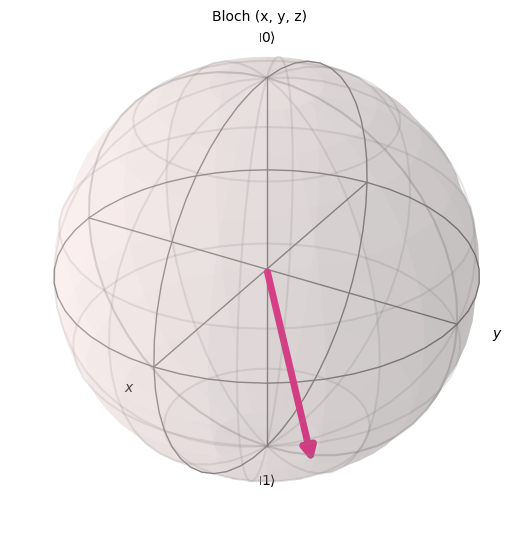

In [9]:
from qiskit.visualization import plot_bloch_vector
x = 1
y = 1
z = -1 
coef = [x, y, z]
norm = np.linalg.norm(coef)
plot_bloch_vector(coef/norm, title="Bloch (x, y, z)")

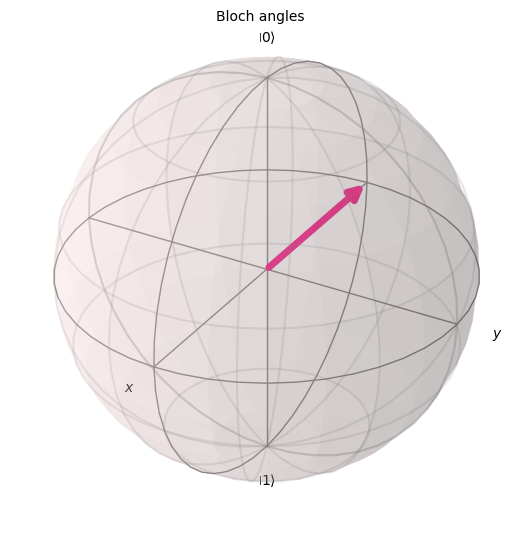

In [39]:
# You can use spherical coordinates instead of cartesian.
theta_by_2 = np.pi/2
phi = np.pi
plot_bloch_vector([1, theta_by_2, phi], coord_type='spherical', title="Bloch angles")

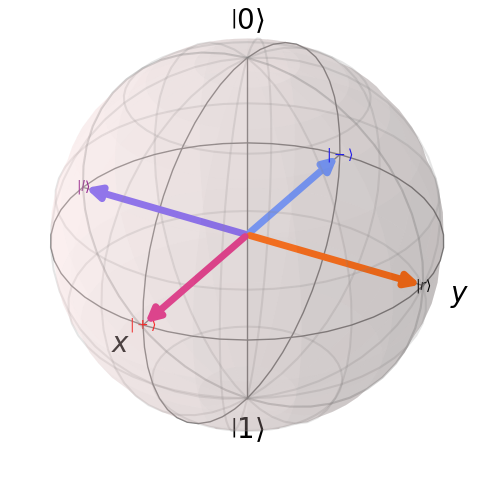

In [15]:
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization.bloch import Bloch
import numpy as np

plus = [1, 0, 0]
minus = [-1,0, 0]
r = [0, 1, 0]
l = [0, -1, 0]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')
B = Bloch(axes=ax)
B.add_vectors([plus, minus, r, l])
B.add_annotation(plus, r'$|+\rangle$', fontsize=10, color="red")
B.add_annotation(minus, r'$|-\rangle$', fontsize=10, color="blue")
B.add_annotation(r, r'$|r\rangle$', fontsize=10)
B.add_annotation(l, r'$|l\rangle$', fontsize=10, color="purple")
B.render()

plt.show()


## Measurement
* First one selects a basis for the measurement.
* $\{\ket{0},\ket{1}\}$ is called **standard basis**.
* Write the state in the chosen basis.
* For example, we can choose $\ket{+},\ket{-}$ as our basis. Then the state $\ket{\psi} = a\ket{0} + b\ket{1}$ can be written as $$\ket{\psi} = \frac{a + b}{\sqrt{2}}\ket{+} + \frac{a-b}{\sqrt{2}}\ket{-}$$
* Measurement performed on $\ket{\psi}$ in standard basis results in 
    * $\ket{0}$ with probability $|a|^2$ or
    * $\ket{1}$ with probability $|b|^2$
* Measurement performed on $\ket{\psi}$ in $\{\ket{+},\ket{-}\}$ basis results in
    * $\ket{+}$ with probability $|\frac{a+b}{\sqrt{2}}|^2$, or
    * $\ket{-}$ with probability $|\frac{a-b}{\sqrt{2}}|^2$
* The measurement in which the final state is one of the chosen (orthogonal) basis states is known as **projective measurement**.
* In qiskit, the measurement is always done in standard basis.
    * To perform measurement in another basis, we need to rotate to standard basis.

In [10]:
from qiskit.quantum_info import Statevector
import numpy as np

a = 1/np.sqrt(2)
b = 1j/np.sqrt(2)
coef = [a, b]
psi = Statevector(coef)
outcome, result = psi.measure() # Measurement
print("A qubit state:")
display(psi.draw("latex"))
print(outcome)
display(result.draw("latex"))

A qubit state:


<IPython.core.display.Latex object>

1


<IPython.core.display.Latex object>

# Two qubits
* Formally, the Hilbert space of a two qubit system is equal to tensor product of Hilbert spaces of each of the qubits, written as $$\mathcal{H}^{\otimes 2} = \mathcal{H}\otimes\mathcal{H}$$
* Two qubit basis vectors are
        $$
        \begin{align*}
            0\equiv 00 &\to |00\rangle = |0\rangle\otimes|0\rangle\equiv |0\rangle\\
            1\equiv 01 &\to |01\rangle = |0\rangle\otimes|1\rangle\equiv |1\rangle\\
            2\equiv 10 &\to |10\rangle = |1\rangle\otimes|0\rangle\equiv |2\rangle\\
            3\equiv 11 &\to |11\rangle = |1\rangle\otimes|1\rangle\equiv |3\rangle\\
        \end{align*}
        $$
* This pattern is generalized for any number of qubits.
* An $n$ qubit state lies in $2^n$ dimensional vector space with basis vectors written as $|x\rangle$ where $x$ is a string of 0s and 1s of length $n$.
* State of two qubit system is a vector obtained as linear combination of basis states $\{\ket{00}, \ket{01}, \ket{10}, \ket{11}\}$ written as $$\ket{\psi} = a\ket{00} + b\ket{01} + c\ket{10} + d\ket{11}$$ where $a,b,c,d$ are complex numbers and satisfy the normalization condition $$|a|^2 + |b|^2 + |c|^2 + |d|^2 = 1$$ 

In [26]:
from qiskit.quantum_info import Statevector
import numpy as np

# 1. Initialize from a custom NumPy array (the coefficients a,b,c,d)
# Basis order: |00>, |01>, |10>, |11>
a = 1/2
b = a
c = a
d = a
coeff = [a,b,c,d]
norm = np.linalg.norm(coeff) # normalize arrays
coeff_norm = coeff/norm

ket = Statevector(coeff_norm)

ket.draw('latex') 

<IPython.core.display.Latex object>

## Random quantum state
* use `random_statevector(n)` to create random state of dimension `n`.

In [21]:
from qiskit.quantum_info import random_statevector
psi_2 = random_statevector(4) # two qubits
psi_2.draw('latex')

<IPython.core.display.Latex object>

## Ordering in qiskit
* The qubits in qiskit are arranged from right to left $$\ket{q_{n-1}q_{n-2}\cdots q_1q_0}$$

## Measurement
* A full measurement performed on $\ket{\psi} = a\ket{00} + b\ket{01} + c\ket{10} + d\ket{11}$ results in
    * $\ket{00}$ with probability $|a|^2$, or
    * $\ket{01}$ with probability $|b|^2$, or
    * $\ket{10}$ with probability $|c|^2$, or
    * $\ket{11}$ with probability $|d|^2$
* It is possible to perform measurement on only one of the qubits.
### Measurement on 1st qubit (rightmost)
* Express the state as $\ket{\psi} = (a\ket{0} + c\ket{1})\ket{0} + (b\ket{0} + d\ket{1})\ket{1}$
* Normalize partial states $a\ket{0} + c\ket{1}$ and $b\ket{0} + d\ket{1}$ of the 2nd qubit.
    * Normalization factors are $\sqrt{|a|^2 + |c|^2}$ and $\sqrt{|b|^2 + |d|^2}$, respectively.
* Rewrite the state 
$$
\begin{aligned}\ket{\psi} &= \sqrt{|a|^2 + |c|^2}\times\frac{1}{\sqrt{|a|^2 + |c|^2}}(a\ket{0} + c\ket{1})\ket{0}\\ &+ \sqrt{|b|^2 + |d|^2}\times\frac{1}{\sqrt{|b|^2 + |d|^2}}(b\ket{0} + d\ket{1})\ket{1}\end{aligned}$$
* Perform measurement on the 1st qubit resulting in
    * $\frac{1}{\sqrt{|a|^2 + |c|^2}}(a\ket{0} + c\ket{1})\ket{0}$ with probability $|a|^2 + |c|^2$
    * $\frac{1}{\sqrt{|b|^2 + |d|^2}}(b\ket{0} + d\ket{1})\ket{0}$ with probability $|b|^2 + |d|^2$

### Exercise
* Describe measurement on 2nd qubit as above.
* What will be the states of the 1st qubit after measurement performed on the 2nd qubit when the combined states are
    1. $\frac{1}{\sqrt{2}}[\ket{00} + \ket{11}]$
    2. $\frac{1}{\sqrt{2}}[\ket{0}\frac{\ket{0}+\ket{1}}{\sqrt{2}} + \ket{1}\frac{\ket{0} + \ket{1}}{\sqrt{2}}]$
    3. $\frac{1}{2\sqrt{2}}\ket{00} + \frac{1}{2\sqrt{2}}\ket{01} + \frac{\sqrt{3}}{2\sqrt{2}}\ket{10} + \frac{\sqrt{3}}{2\sqrt{2}}\ket{11}$


In [32]:
from qiskit.quantum_info import Statevector
import numpy as np

# 1. Initialize from a custom NumPy array (the coefficients a,b,c,d)
# Basis order: |00>, |01>, |10>, |11>
a = 1/2
b = a
c = a
d = a
coeff = [a,b,c,d]
norm = np.linalg.norm(coeff) # normalize arrays
coeff_norm = coeff/norm

ket = Statevector(coeff_norm)

ket.draw('latex') 

<IPython.core.display.Latex object>

In [29]:
# Measure all qubits
outcome, collapsed_ket = ket.measure()

print(f"outcome: {outcome}")
collapsed_ket.draw("latex")

outcome: 00


<IPython.core.display.Latex object>

In [31]:
# Measure only 1st qubit
outcome, measured_ket0 = ket.measure([0])
prob_q0 = ket.probabilities([0])
print(f"outcome: {outcome}")
print(f"probability: {prob_q0}")
measured_ket0.draw("latex")

outcome: 0
probability: [0.5 0.5]


<IPython.core.display.Latex object>

## Entanglement
* What are the states of individual qubits when $\ket{\psi}$ is the state of the two-qubit system?
* Consider two possible states $$\begin{aligned}\ket{\psi_s} &= \frac{1}{2}[\ket{00} - \ket{01} + \ket{10} - \ket{11}]\\ \ket{\psi_e} &= \frac{1}{\sqrt{2}}[\ket{00} + \ket{11}]\end{aligned}$$
* The first state can be written as $$\ket{\psi_s} = \frac{\ket{0} + \ket{1}}{\sqrt{2}}\otimes\frac{\ket{0} - \ket{1}}{\sqrt{2}}$$
    * For the first qubit (from right) the state is $$\ket{\psi_0} = \frac{\ket{0} - \ket{1}}{\sqrt{2}}$$
    * For the second qubit, the state is $$\ket{\psi_1} = \frac{\ket{0} + \ket{1}}{\sqrt{2}}$$
* The second state can not be written in the form $\ket{\psi_1}\otimes\ket{\psi_0}$ for any choice of $\ket{\psi_0}$ and $\ket{\psi_1}$.
    * Such states are called **entangled states**.
    * For entangled states, individual subsystems can not be described by a state vector.
* Checking whether a general multipartite system is entangled is NP-complete.

### Exercise
* Which of the states are entangled?
    1. $\frac{1}{2}[\ket{00} + \ket{01} + \ket{10} + \ket{11}]$
    2. $\frac{1}{2\sqrt{2}}\ket{00} + \frac{\sqrt{3}}{2\sqrt{2}}\ket{01} + \frac{1}{2\sqrt{2}}\ket{10} + \frac{\sqrt{3}}{2\sqrt{2}}\ket{11}$
    3. $\frac{3}{5}\ket{01} + \frac{4}{5}\ket{10}$

# Density operators
* If statevectors can not be assigned to individual qubits, how do can we describe them?
* This is done using density operators.
* The idea is to start with the density operator of the two-qubit system and then compute **partial trace** to obtain **reduced density operator** for each qubit.
* To compute these, let's first introduce inner and outer product.

## Inner product
* Inner product is a function $f: V\times V \to C$ that maps two vectors to a complex number.
* It is generalization of the dot product of standard vector calculus, it keeps track of angle between vectors.
* Inner product of $\ket{\phi}$ with $\ket{\psi}$ is denoted as $\langle\phi|\psi\rangle$ obtained by multiplying $\bra{\phi}$ to $\ket{\psi}$.
* When $\langle\phi|\psi\rangle = 0$, we say the vectors are **orthogonal**.
            $$\begin{aligned}\langle 0|1\rangle = 0 = \langle 1|0\rangle\end{aligned}$$
* For unit vectors, inner product is 1.
        $$\begin{aligned}\langle 0|0\rangle = 1 = \langle 1|1\rangle\end{aligned}$$
* **Linearity**: $\langle\psi|(a\ket{0} + b\ket{1}) = a\inpro{\psi}{0} + b\inpro{\psi}{1}$
* **Conjugate**: $\inpro{\psi}{\phi} = \inpro{\phi}{\psi}^*$
* **Positivity**: $\inpro{\psi}{\psi}\geq 0$, equality only if $\ket{\psi} = 0$


In [29]:
from qiskit.quantum_info import Statevector
import numpy as np

# Define two statevectors
psi = Statevector.from_label('0')      # |0>
phi = Statevector.from_label('+')      # |+> = (|0> + |1>) / sqrt(2)

# kets latex
psi_L = r"$|\psi\rangle $"
phi_L = r"$|\phi\rangle $"


# Calculate the inner product <phi | psi>
result = phi.inner(psi)
showState(psi_L, psi)
showState(phi_L, phi)
print(f"Inner Product <phi|psi>: {result}")
# Output: (0.7071067811865475+0j) which is 1/sqrt(2)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Inner Product <phi|psi>: (0.7071067811865475+0j)


## Outer product
* Outer product is a linear function $g : V\times V \to \mathcal{L}(V)$ that maps two vectors to a linear operator.
* The outer product of $\ket{\phi}$ with $\ket{\psi}$ is obtained by multiplying $\ket{\phi}$ to $\bra{\psi}$, denoted as $|\phi\rangle\langle\psi|$.
* Outer product is like multiplying a row to a column resulting in a matrix.
* Notice that we used outer product to define density operator.
* The outer product of two qubit states are written as 
                $$\begin{aligned}
                |00\rangle\langle 00| &= |0\rangle\langle 0|\otimes |0\rangle\langle 0|\\
                |01\rangle\langle 10| &= |0\rangle\langle 1|\otimes |1\rangle\langle 0|\\
                \end{aligned}$$
* In qiskit, use `outer` function from `numpy` to compute the matrix and `Operator` from `qiskit.quantum_info` to convert to an operator.

In [30]:
from qiskit.quantum_info import Statevector, Operator, random_statevector
import numpy as np

# Define two statevectors
psi = random_statevector(4) # two qubits
phi = random_statevector(4)  
psi_L = r"$|\psi\rangle $"
phi_L = r"$|\phi\rangle $"
# Compute outer product |psi><phi|
# np.outer(u, v) computes u * conj(v)
outer_matrix = np.outer(psi.data, np.conj(phi.data))

# Convert to a Qiskit Operator
op = Operator(outer_matrix)

showState(psi_L, psi)
showState(phi_L, phi)
print("Outer Product Matrix:")
# print(op.data)
op.draw('latex')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Outer Product Matrix:


<IPython.core.display.Latex object>

### Inner product and outer product
* An outer product can **act** on a ket.
    $$|\phi\rangle\langle\psi|\cdot\ket{k} = \ket{\phi}\cdot\langle\psi|k\rangle = c\ket{\phi}$$
    where $c= \langle\psi|k\rangle$ is the inner product (a complex number).
* A bra can act on an outer product from the left.
    $$\bra{k}\cdot|\phi\rangle\langle\psi| = \langle k|\phi\rangle\cdot\bra{\psi} = c\bra{\psi}$$
    where $c= \langle k|\phi\rangle$ is the inner product (a complex number).
* We can combine both operations at the same time, i.e. a bra acts from the left and a ket acts from the right on an outer product.
    $$\bra{b}\cdot|\phi\rangle\langle\psi|\cdot\ket{k} = \langle b|\phi\rangle\cdot\langle\psi|k\rangle = c_1c_2$$
  which results in a complex number.


### Trace
* Trace of a matrix is defined as the sum of diagonal entries.
* For a single qubit, it's density operator can be expressed as 
$$\begin{aligned}\rho &= a|0\rangle\langle 0| + b|0\rangle\langle 1| + c|1\rangle\langle 0| + d|1\rangle\langle 1|\\ &= \begin{bmatrix}a & b\\ c & d\end{bmatrix}\end{aligned}$$
* As trace is sum of diagonals ($a + d$), we can define 
     $$tr(\rho) = \langle 0|\rho|0\rangle + \langle 1|\rho|1\rangle$$

### Exercise
* Calculate of Pauli matrices.
* Show that trace is a cyclic function, i.e. $tr(AB) = tr(BA)$

## Partial trace
* Density operator for a two qubit system can be written as 
$$\rho = a|0\rangle\langle 0|\otimes|0\rangle\langle 0| + \text{all combinations of 0s and 1s}$$
* This will be $2^n\times 2^n$ matrix, here $n=2$.
* Partial trace is applying trace to only one part of the outer products.
    * Tracing out 1 (rightmost)
        $$\rho_2 = tr_1(\rho) = a|0\rangle\langle 0|\cdot \langle 0|0\rangle\langle 0| 0\rangle + a|0\rangle\langle 0|\cdot \langle 1|0\rangle\langle 0| 1\rangle + \text{other terms}
        $$
        $$
        \begin{bmatrix}
            \outpro{0}{0}\begin{bmatrix}
                \inpro{0}{0}^2 & 0\\
                    0  & \inpro{1}{1}^2
            \end{bmatrix} & \outpro{0}{1}\begin{bmatrix}
                \inpro{0}{0}^2 & 0\\
                    0  & \inpro{1}{1}^2
            \end{bmatrix}\\
            \\
            \outpro{1}{0}\begin{bmatrix}
                \inpro{0}{0}^2 & 0\\
                    0  & \inpro{1}{1}^2
            \end{bmatrix} & \outpro{1}{1}\begin{bmatrix}
                \inpro{0}{0}^2 & 0\\
                    0  & \inpro{1}{1}^2
            \end{bmatrix}
        \end{bmatrix}
        $$
    * Tracing out 2
        $$\rho_1 = tr_2(\rho) = a\langle 0|0\rangle\langle 0| 0\rangle\cdot|0\rangle\langle 0|  + a\langle 1|0\rangle\langle 0| 1\rangle\cdot|0\rangle\langle 0| + \text{other terms}$$
    * In general, $\rho_1\neq \rho_2$
* Tracing out 1 converts states of 1 to complex number.
* Tracing out 2 converts states of 2 to complex number.
* In both cases, a $4\times 4$ matrix becomes $2\times 2$ matrix.
* Partial tracing is like discarding a qubit.
    * Whatever remains is called **reduced density operator** describing the remaining system.
* In case of entangled system, it is this reduced density operator that is used to describe parts of the system.
* For reduced density operator, we can write $$\rho = \frac{1}{2}(I + \vec{r}\cdot\vec{\sigma})$$ where $|\vec{r}|\leq 1$, i.e. point may lie inside the Bloch sphere unlike pure states that must lie on the sphere.
    * When $\vec{r} = 0, \rho = I/2$, i.e. the point lies at the center of the sphere.

### Exercise
Calculate reduced density operators 
* $\ket{00}$
* $\frac{1}{\sqrt{2}}[\ket{00} + \ket{10}]$ 
* $\frac{1}{\sqrt{2}}[\ket{00} + \ket{11}]$ 
* $\frac{1}{\sqrt{2}}[\ket{01} - \ket{10}]$ 
* $\frac{\sqrt{3}}{2}\ket{01} + \frac{1}{2}\ket{10}]$ 

In [ ]:
from qiskit.quantum_info import Statevector, partial_trace

# Example for Exercise 4
psi = Statevector([1/2, 1/2, 1/2, 1/2]) # Order |00>, |01>, |10>, |11>
psi_L = r"$|\psi\rangle$"
rho0 = partial_trace(psi, [1]) # Trace out qubit 1 (index 1)
rho1 = partial_trace(psi, [0])
showState(psi_L, psi)
display(rho0.draw("latex"))
display(rho1.draw("latex"))
# print(rho0.data)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Visualizing two qubit states
### Multivector on Bloch sphere
* Plot reduced density matrices for each qubit.
* Use `plot_bloch_multivector`

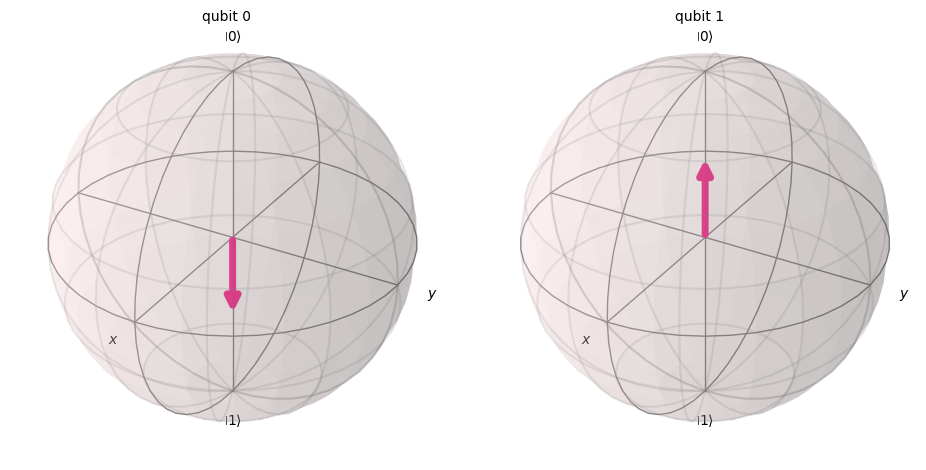

In [35]:
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(psi)

## Qsphere
* For a state $\ket{\psi}$, the coefficients of each computational basis $\ket{k}$ can be written as $\sqrt{p_k}e^{i\varphi_k}$.
* Many visualization methods find a way to represent these coefficients. `plot_state_qsphere`
* In qsphere, a sphere is sliced horizontally creating layers (latitudes).
* At the North pole, all zeros state $|000...\rangle$ is place and at the South pole, all ones state $\ket{111...}$ is placed.
* For any other state a layer is assigned depending on the number of 0s or 1s.
    * For example, states with only one 1 are assigned layer just below North pole.
* Size of disk shows $\sqrt{p_k}$ and phase $\varphi_k$ is shown by color.

<IPython.core.display.Latex object>

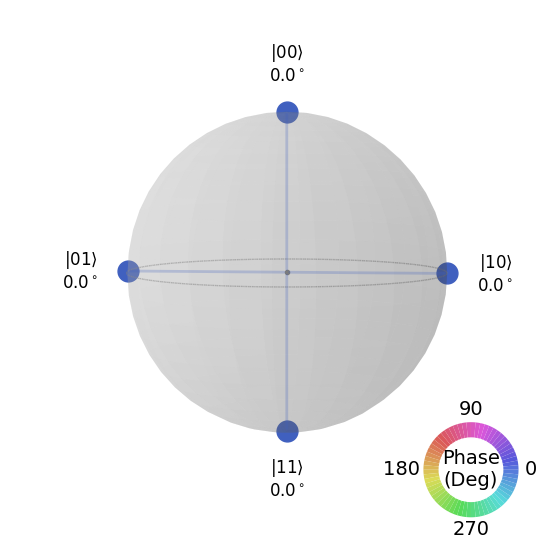

In [14]:
from qiskit.visualization import plot_state_qsphere
showState(psi_L, psi)
plot_state_qsphere(psi, show_state_phases = True, use_degrees = True)

## Other Visualization methods
* qiskit.visualization
    * plot_histogram
    * plot_state_city
    * plot_bloch_multivector
    * plot_state_hinton
    * plot_state_paulivec
    * plot_state_qsphere

## Multi-qubit systems
* For $n$ qubit systems, the basis states are $\ket{x}$ where $x$ is all possible sequence of 0s and 1s of length $n$. $$x = 00101011\quad \ket{x}=\ket{00101011}$$
* Again we require the states to be unit. $$\ket{\psi} = \sum_x c_x\ket{x}$$ such that $\sum_x|c_x|^2 = 1$
* There are $2^n$ basis vectors for $n$ qubits.
* Visualization of multi-qubit system is challenging.
* A key aspect is determining amount of entanglement in the system.

## Entanglement as a resource
* Maximally entangled two qubit states
$$
\begin{aligned}
\ket{\psi} &= \frac{1}{\sqrt{2}}[\ket{00} + \ket{11}]\\
\ket{\psi} &= \frac{1}{\sqrt{2}}[\ket{01} + \ket{10}]\\
\ket{\psi} &= \frac{1}{\sqrt{2}}[\ket{01} - \ket{10}]\\
\ket{\psi} &= \frac{1}{\sqrt{2}}[\ket{00} - \ket{11}]
\end{aligned}
$$

* There are various ways to compute or characterize entanglement.
* **von Neumann entropy**: $S(\rho_1) = -Tr(\rho_1\log_2\rho_1)=-(\lambda_1\log_2\lambda_1 + \lambda_2\log_2\lambda_2)$
* **Concurrence**: $C(\ket{\psi}) = 2|ad-bc|$
* **Negativity**: $\mathcal{N} = \sum_i\frac{|\lambda_i|-\lambda_i}{2}$ (negative eigenvalues of $\rho^{T_A}$)
* **Entanglement of formation** 
* **Schmidt decomposition**


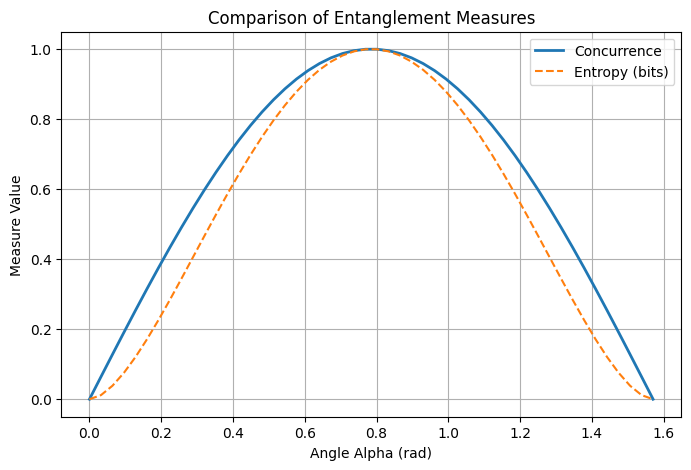

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, concurrence, entropy, partial_trace

alphas = np.linspace(0, np.pi/2, 50)
conc_vals = []
ent_vals = []

for a in alphas:
    # Create the state cos(a)|00> + sin(a)|11>
    psi = Statevector([np.cos(a), 0, 0, np.sin(a)])
    
    # Calculate Concurrence
    conc_vals.append(concurrence(psi))
    
    # Calculate Von Neumann Entropy of the reduced state (base 2)
    rho_0 = partial_trace(psi, [1])
    ent_vals.append(entropy(rho_0, base=2))

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(alphas, conc_vals, label='Concurrence', linewidth=2)
plt.plot(alphas, ent_vals, label='Entropy (bits)', linestyle='--')
plt.xlabel('Angle Alpha (rad)')
plt.ylabel('Measure Value')
plt.title('Comparison of Entanglement Measures')
plt.legend()
plt.grid(True)
plt.show()